In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("scores_data.csv")
df.head()


,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [3]:
df.columns = df.columns.str.strip()
df['Score'] = df['Score'].str.extract(r'(\d+)').astype(int)
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6
1,AI_ELITE_7,uid_148,6
2,AI_ELITE_7,uid_147,7
3,AI_ELITE_7,uid_146,7
4,AI_ELITE_7,uid_145,4


In [5]:
df['Score'].describe()

,Score
count,149.000000
mean,4.382550
std,1.592199
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


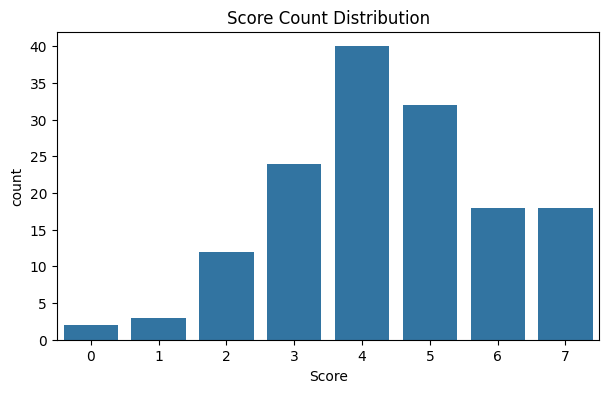

In [6]:
plt.figure(figsize=(7,4))
sns.countplot(x='Score', data=df)
plt.title("Score Count Distribution")
plt.show()


In [7]:
batch_stats = df.groupby("Batch")['Score'].agg(['count', 'mean', 'min', 'max'])
batch_stats


,count,mean,min,max
Batch,,,,
AI_ELITE_4,48,3.791667,0,7
AI_ELITE_6,48,4.229167,0,7
AI_ELITE_7,53,5.056604,2,7


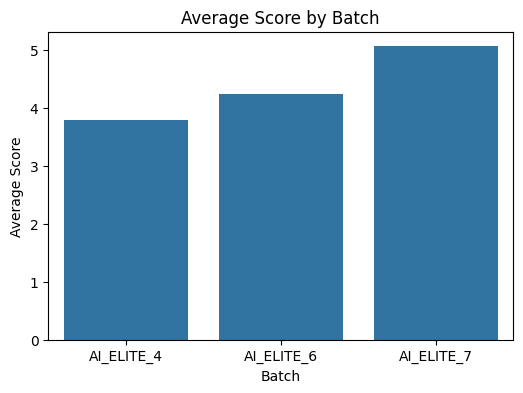

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x=batch_stats.index, y=batch_stats['mean'])
plt.title("Average Score by Batch")
plt.ylabel("Average Score")
plt.show()


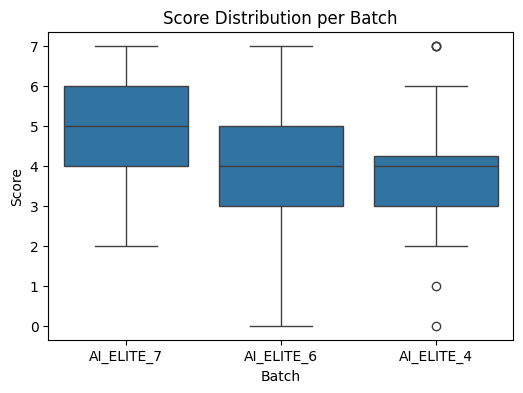

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Batch', y='Score', data=df)
plt.title("Score Distribution per Batch")
plt.show()


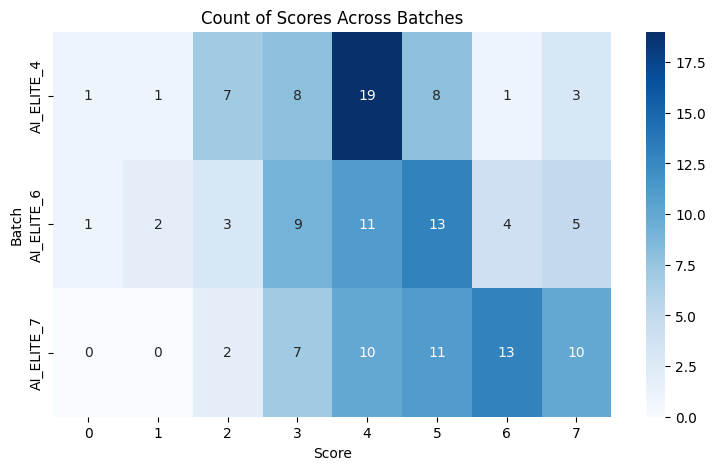

In [10]:
score_dist = df.pivot_table(index='Batch', columns='Score', aggfunc='size', fill_value=0)

plt.figure(figsize=(9,5))
sns.heatmap(score_dist, annot=True, cmap="Blues")
plt.title("Count of Scores Across Batches")
plt.show()


In [11]:
print("Best Performing Batch:", batch_stats['mean'].idxmax())
print("Lowest Performing Batch:", batch_stats['mean'].idxmin())

print("\nAverage Score for Each Batch:\n", batch_stats['mean'])


Best Performing Batch: AI_ELITE_7
Lowest Performing Batch: AI_ELITE_4

Average Score for Each Batch:
 Batch
AI_ELITE_4    3.791667
AI_ELITE_6    4.229167
AI_ELITE_7    5.056604
Name: mean, dtype: float64
